# 11 — Disk I/O Deep Dive

Analyses **disk reads and writes** for every language across every benchmark.

Key findings from the raw data:
- **k-nucleotide** and **regex-redux** are the only benchmarks with meaningful disk reads (~26 MB and ~52 MB respectively) — both read a large FASTA input file.
- All other benchmarks show only ~0.6–0.9 MB of reads (binary/runtime load at startup).
- Disk **writes** are negligible across all benchmarks (<0.12 MB).

Charts produced:
1. Overview heatmap — mean disk reads per language × benchmark
2. Overview heatmap — mean disk writes per language × benchmark
3. Grid bar — disk reads per benchmark, languages ranked
4. Grid bar — disk writes per benchmark, languages ranked
5. Deep dive strip plots — k-nucleotide & regex-redux reads (per run)
6. Ranked bars — k-nucleotide & regex-redux reads
7. Scatter — reads vs. execution time for the two I/O-heavy benchmarks
8. Summary table — mean reads + writes per language (all benchmarks)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

RUNS_CSV = Path('../results/results_clean_runs.csv')
FIGS_DIR = Path('../results/figs/disk_io')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family'   : 'serif',
    'font.size'     : 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.dpi'    : 150,
    'savefig.dpi'   : 300,
})

def save(name: str):
    plt.savefig(FIGS_DIR / f'{name}.pdf', bbox_inches='tight')
    plt.show()

def find_col(df: pd.DataFrame, keyword: str) -> str:
    matches = [c for c in df.columns if keyword in c]
    if not matches:
        raise KeyError(f'No column matching "{keyword}"')
    return matches[0]

---
## 1. Load data

In [14]:
runs = pd.read_csv(RUNS_CSV)
_id_cols = {'run_id', 'measured_at', 'language', 'benchmark'}
_metric_cols = [c for c in runs.columns if c not in _id_cols]
means = runs.groupby(['language', 'benchmark'])[_metric_cols].mean().reset_index()

COL_R    = find_col(runs, 'disk_total_read')
COL_W    = find_col(runs, 'disk_total_write')
COL_TIME = find_col(runs, 'phase_time')

print(f'Per-run rows : {len(runs)}')
print(f'Mean rows    : {len(means)}')
print(f'Read col     : {COL_R}')
print(f'Write col    : {COL_W}')

# Per-benchmark mean reads and writes (across all languages)
bm_summary = means.groupby('benchmark')[[COL_R, COL_W]].mean().round(4)
bm_summary.columns = ['Mean Read (MB)', 'Mean Write (MB)']
bm_summary.sort_values('Mean Read (MB)', ascending=False)
LANG_DISPLAY = {
    'c': 'C', 'cpp': 'C++', 'csharp': 'C#', 'fsharp': 'F#',
    'nodejs': 'JavaScript', 'dart': 'Dart', 'erlang': 'Erlang',
    'go': 'Go', 'haskell': 'Haskell', 'java': 'Java', 'lua': 'Lua',
    'ocaml': 'OCaml', 'perl': 'Perl', 'php': 'PHP',
    'python': 'Python', 'ruby': 'Ruby', 'rust': 'Rust', 'swift': 'Swift',
}
runs['language'] = runs['language'].replace(LANG_DISPLAY)
means['language'] = means['language'].replace(LANG_DISPLAY)

Per-run rows : 1280
Mean rows    : 144
Read col     : disk_total_read_cgroup_container-container-mb
Write col    : disk_total_write_cgroup_container-container-mb


---
## 2. Heatmaps — reads & writes per language × benchmark

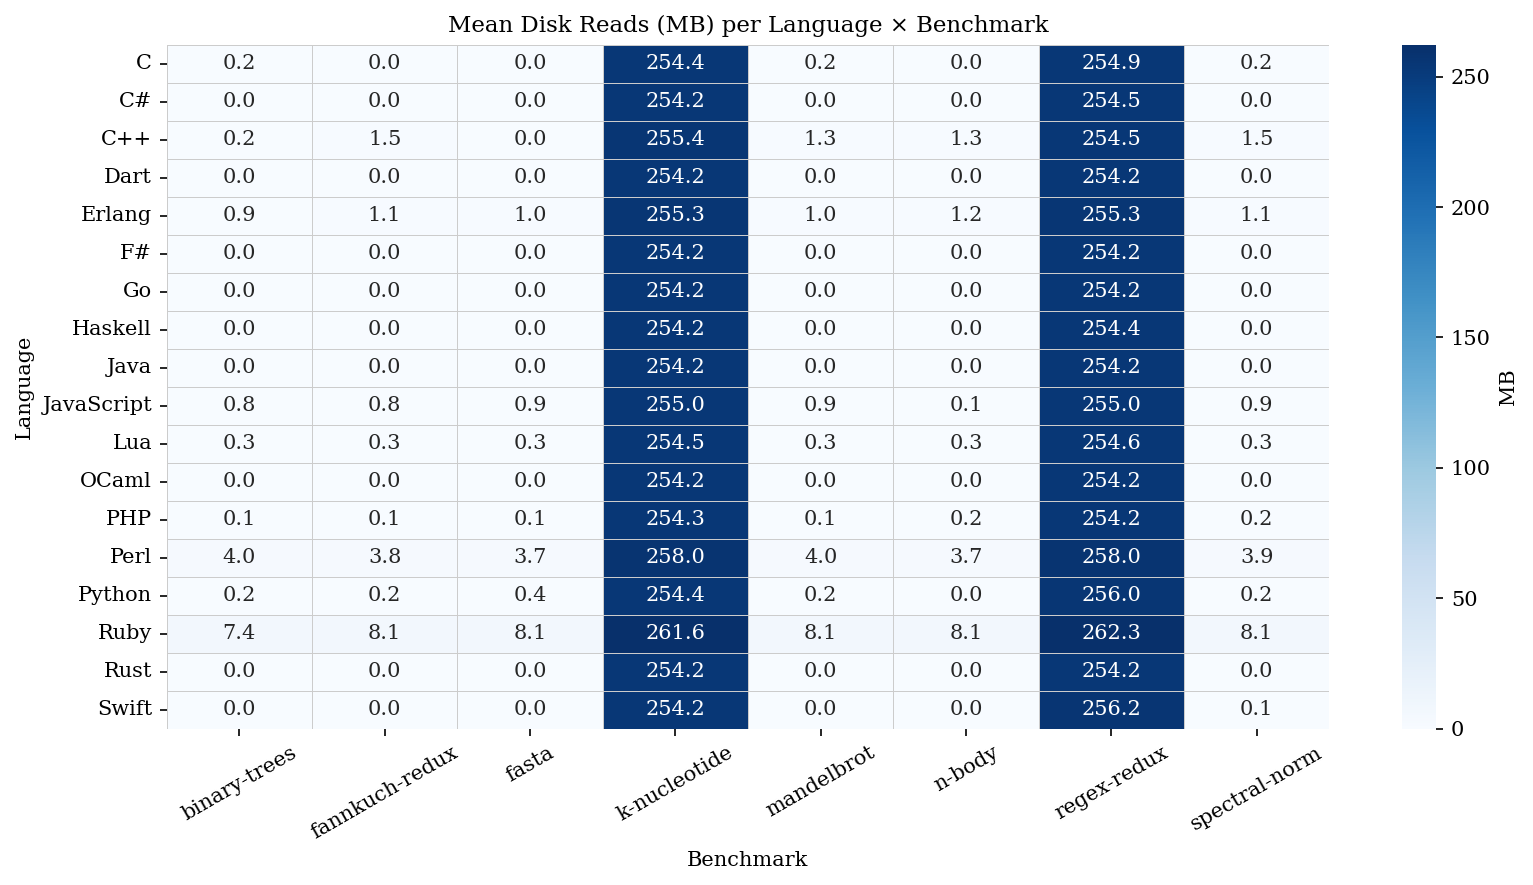

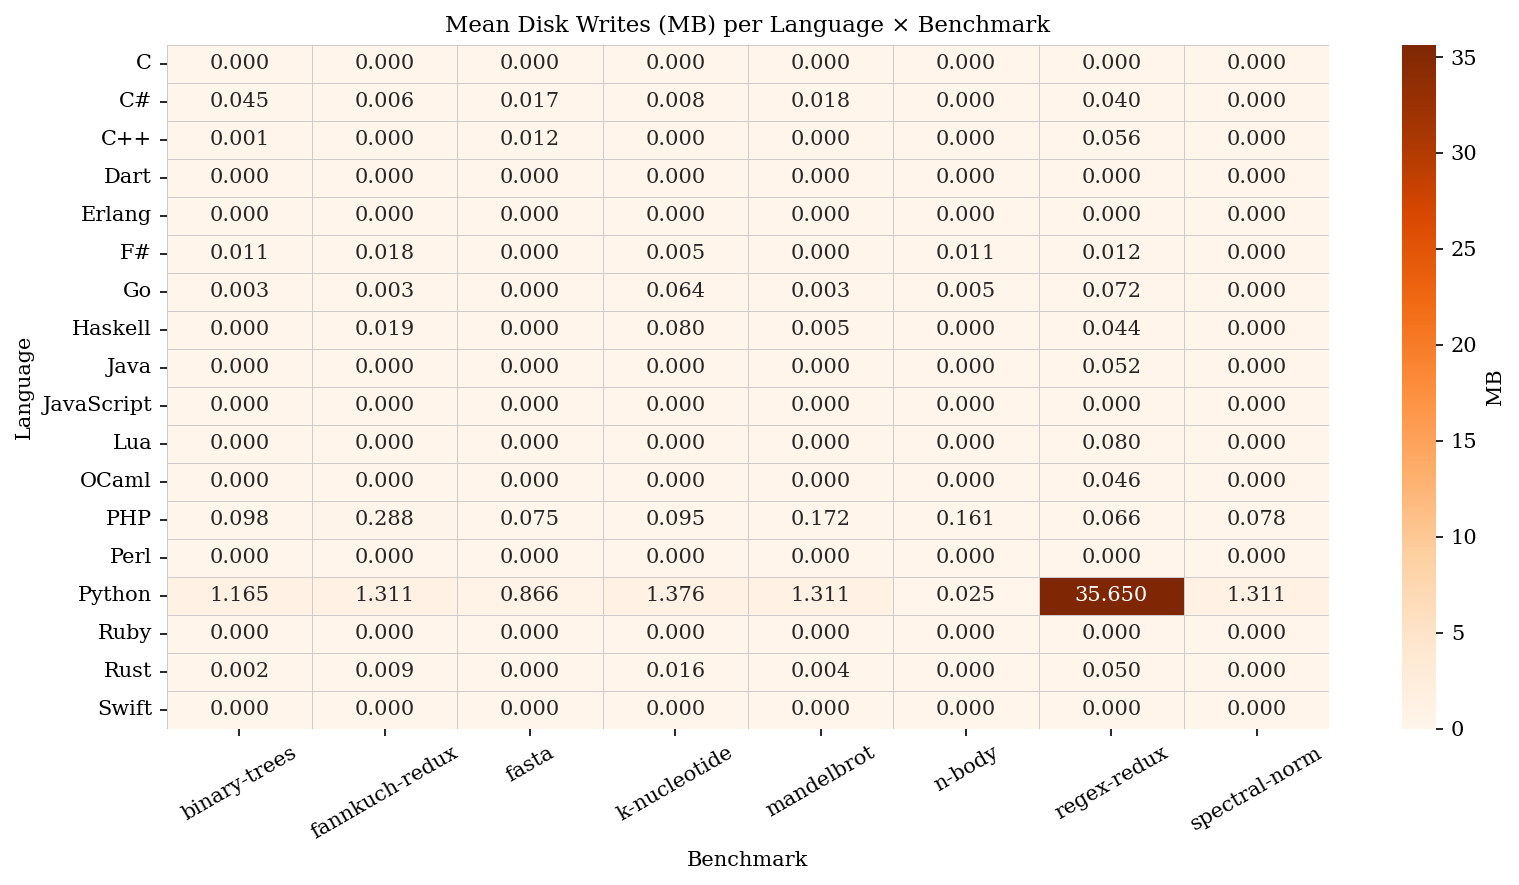

In [15]:
def disk_heatmap(col: str, title: str, fname: str, fmt: str = '.2f', cmap: str = 'Blues'):
    mat = means.pivot(index='language', columns='benchmark', values=col)
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.heatmap(
        mat, annot=True, fmt=fmt, cmap=cmap,
        linewidths=0.4, linecolor='#cccccc',
        cbar_kws={'label': 'MB'},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Benchmark')
    ax.set_ylabel('Language')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    save(fname)

disk_heatmap(COL_R, 'Mean Disk Reads (MB) per Language × Benchmark',  'heatmap_disk_reads',  fmt='.1f', cmap='Blues')
disk_heatmap(COL_W, 'Mean Disk Writes (MB) per Language × Benchmark', 'heatmap_disk_writes', fmt='.3f', cmap='Oranges')

---
## 3. Grid bar charts — reads & writes per benchmark, languages ranked

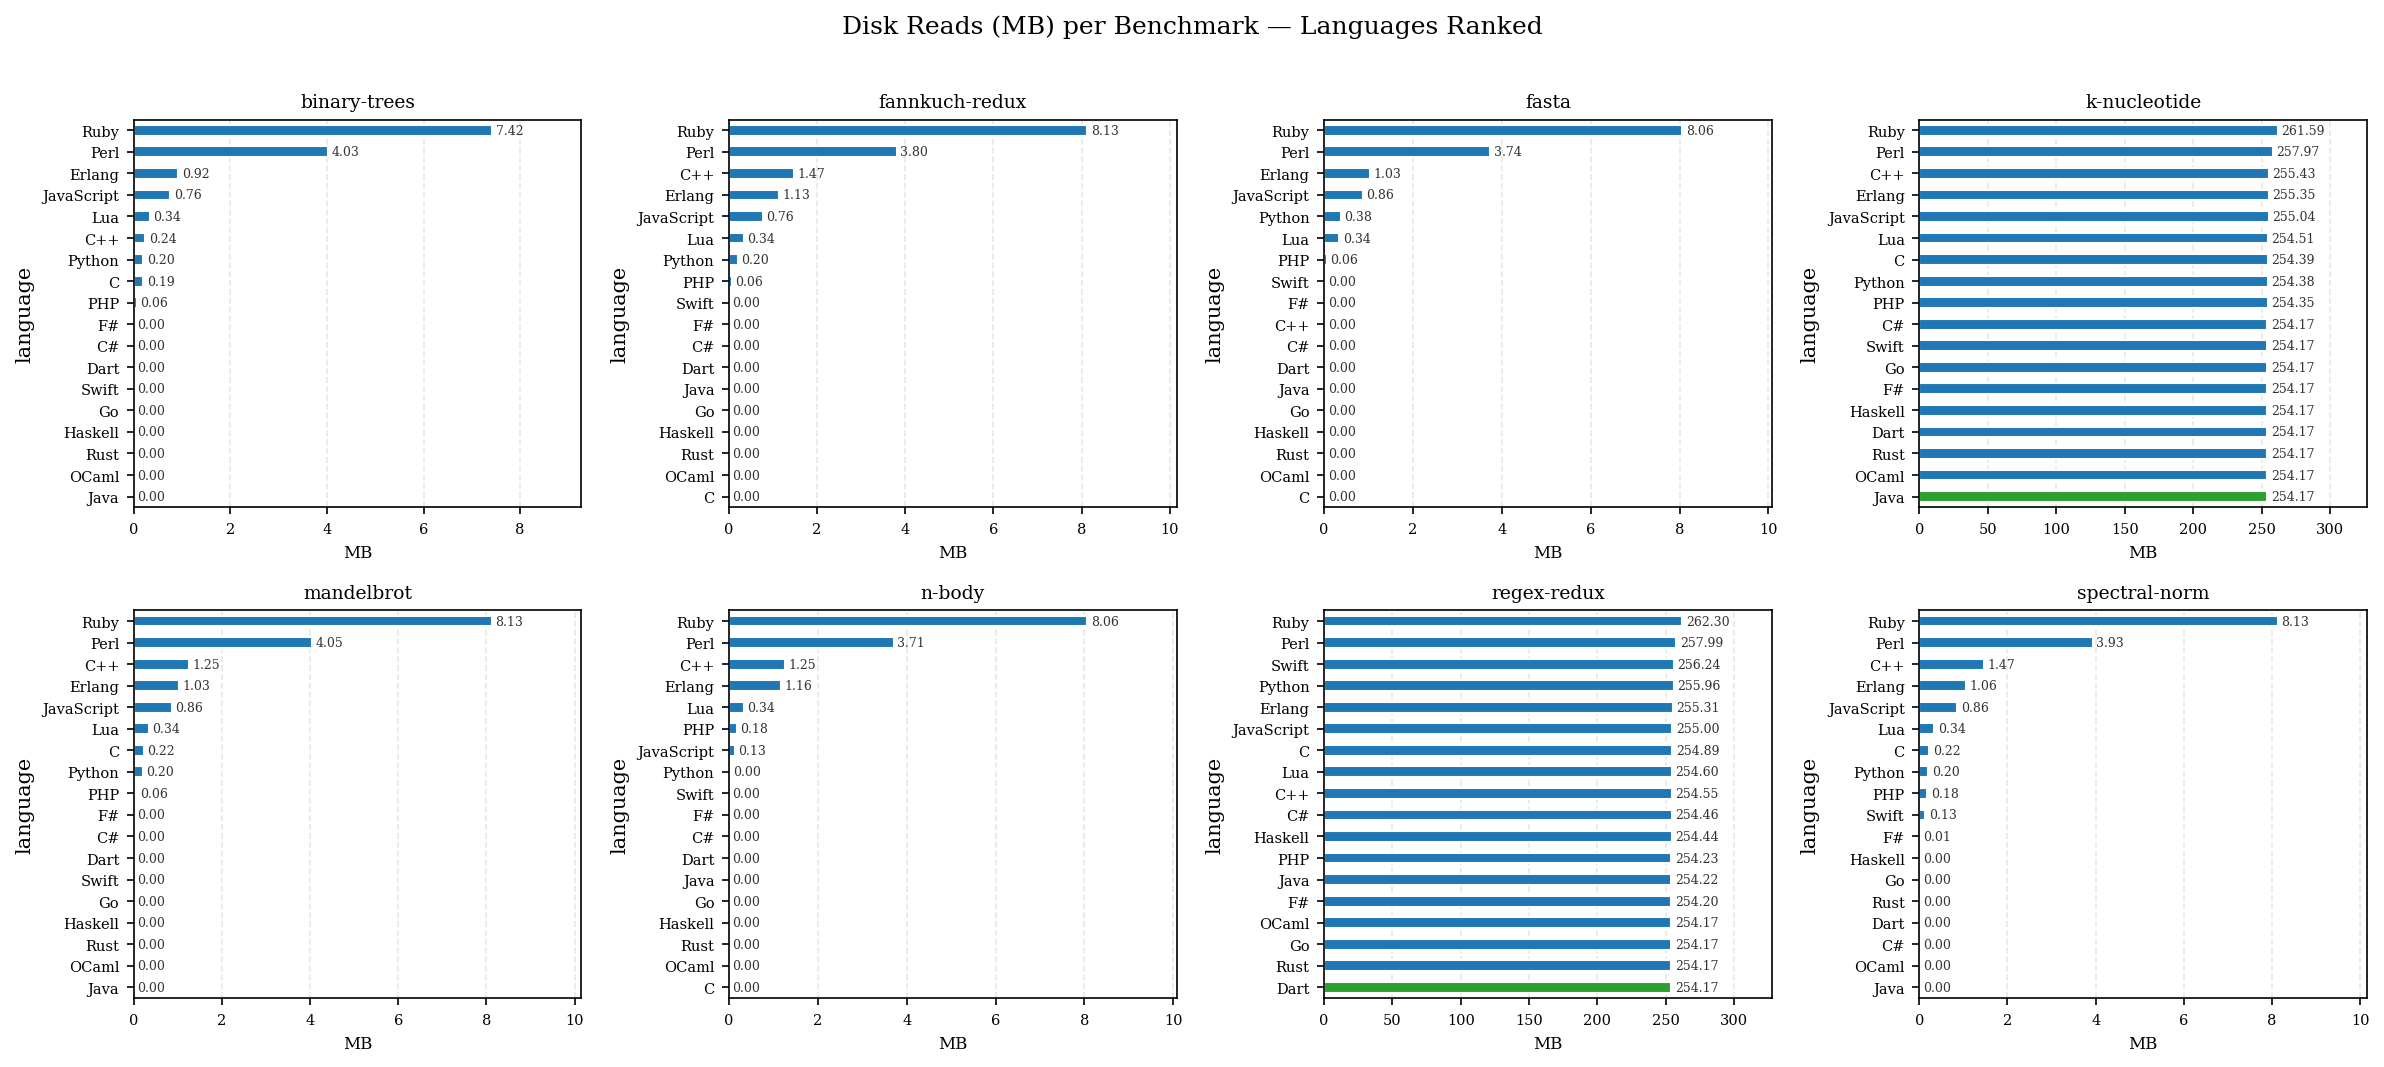

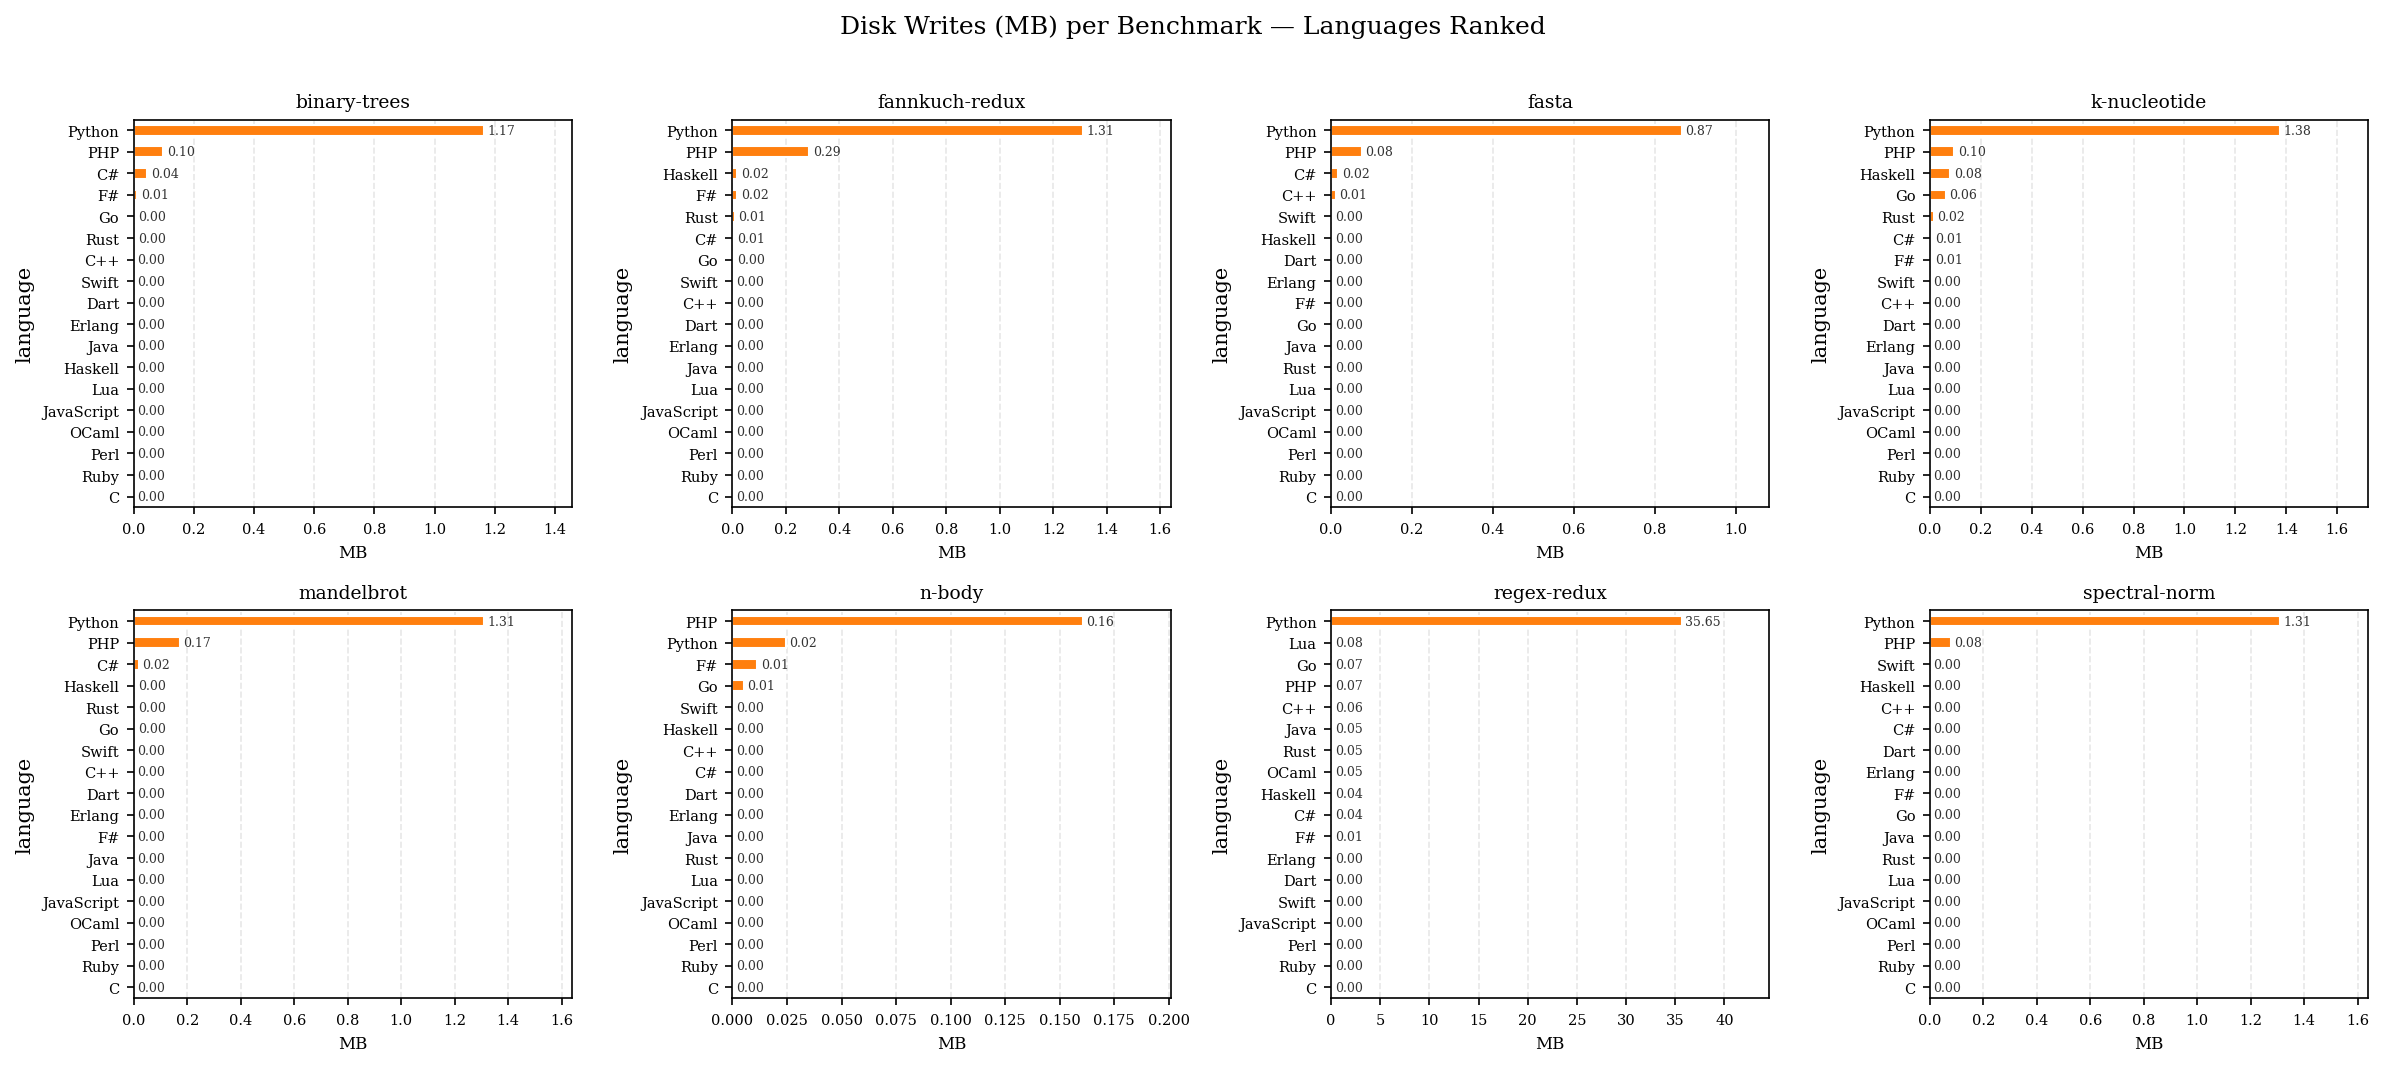

In [16]:
def grid_disk_bars(col: str, unit: str, title: str, fname: str, color: str = '#1f77b4'):
    benchmarks = sorted(means['benchmark'].unique())
    ncols = 4
    nrows = int(np.ceil(len(benchmarks) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharey=False)
    axes = axes.flatten()

    for i, bm in enumerate(benchmarks):
        ax = axes[i]
        sub = means[means['benchmark'] == bm].set_index('language')[col].sort_values()
        colors = ['#2ca02c'] + [color] * (len(sub) - 1)
        sub.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

        x_max = sub.max()
        for bar, val in zip(ax.patches, sub.values):
            ax.text(
                bar.get_width() + x_max * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}',
                va='center', ha='left', fontsize=6, color='#333333',
            )

        ax.set_xlim(0, x_max * 1.25)
        ax.set_title(bm, fontsize=9)
        ax.set_xlabel(unit, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.xaxis.grid(True, linestyle='--', alpha=0.3)
        ax.set_axisbelow(True)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, y=1.01, fontsize=12)
    plt.tight_layout()
    save(fname)

grid_disk_bars(COL_R, 'MB', 'Disk Reads (MB) per Benchmark — Languages Ranked',  'grid_disk_reads',  color='#1f77b4')
grid_disk_bars(COL_W, 'MB', 'Disk Writes (MB) per Benchmark — Languages Ranked', 'grid_disk_writes', color='#ff7f0e')

---
## 4. Deep dive — k-nucleotide & regex-redux (the only I/O-heavy benchmarks)

Both benchmarks read a large FASTA input file from disk:
- **k-nucleotide**: ~25 MB input
- **regex-redux**: ~50 MB input

All other benchmarks generate their data in memory — disk reads there reflect only binary/runtime loading (~0.6–0.9 MB constant overhead).

In [17]:
IO_BENCHMARKS = ['k-nucleotide', 'regex-redux']

io_runs  = runs[runs['benchmark'].isin(IO_BENCHMARKS)].copy()
io_means = means[means['benchmark'].isin(IO_BENCHMARKS)].set_index(['language', 'benchmark'])

print('Per-run rows for I/O benchmarks:', len(io_runs))
io_runs.groupby(['benchmark', 'language'])[[COL_R, COL_W]].mean().round(3)

Per-run rows for I/O benchmarks: 315


disk_total_read_cgroup_container-container-mb  \
benchmark    language                                                    
k-nucleotide C                                                 254.394   
             C#                                                254.173   
             C++                                               255.427   
             Dart                                              254.173   
             Erlang                                            255.347   
             F#                                                254.173   
             Go                                                254.173   
             Haskell                                           254.173   
             Java                                              254.173   
             JavaScript                                        255.037   
             Lua                                               254.509   
             OCaml                                             254.173   
             PHP                                               254.345   
             Perl                                              257.974   
             Python                                            254.378   
             Ruby                                              261.589   
             Rust                                              254.173   
             Swift                                             254.173   
regex-redux  C                                                 254.890   
             C#                                                254.456   
             C++                                               254.545   
             Dart                                              254.173   
             Erlang                                            255.308   
             F#                                                254.198   
             Go                                                254.173   
             Haskell                                           254.444   
             Java                                              254.222   
             JavaScript                                        254.996   
             Lua                                               254.595   
             OCaml                                             254.173   
             PHP                                               254.226   
             Perl                                              257.987   
             Python                                            255.959   
             Ruby                                              262.300   
             Rust                                              254.173   
             Swift                                             256.242   

                         disk_total_write_cgroup_container-container-mb  
benchmark    language                                                    
k-nucleotide C                                                    0.000  
             C#                                                   0.008  
             C++                                                  0.000  
             Dart                                                 0.000  
             Erlang                                               0.000  
             F#                                                   0.005  
             Go                                                   0.064  
             Haskell                                              0.080  
             Java                                                 0.000  
             JavaScript                                           0.000  
             Lua                                                  0.000  
             OCaml                                                0.000  
             PHP                                                  0.095  
             Perl                                                 0.000  
             Python         

### 4a. Strip plots — per-run disk reads (consistency check)

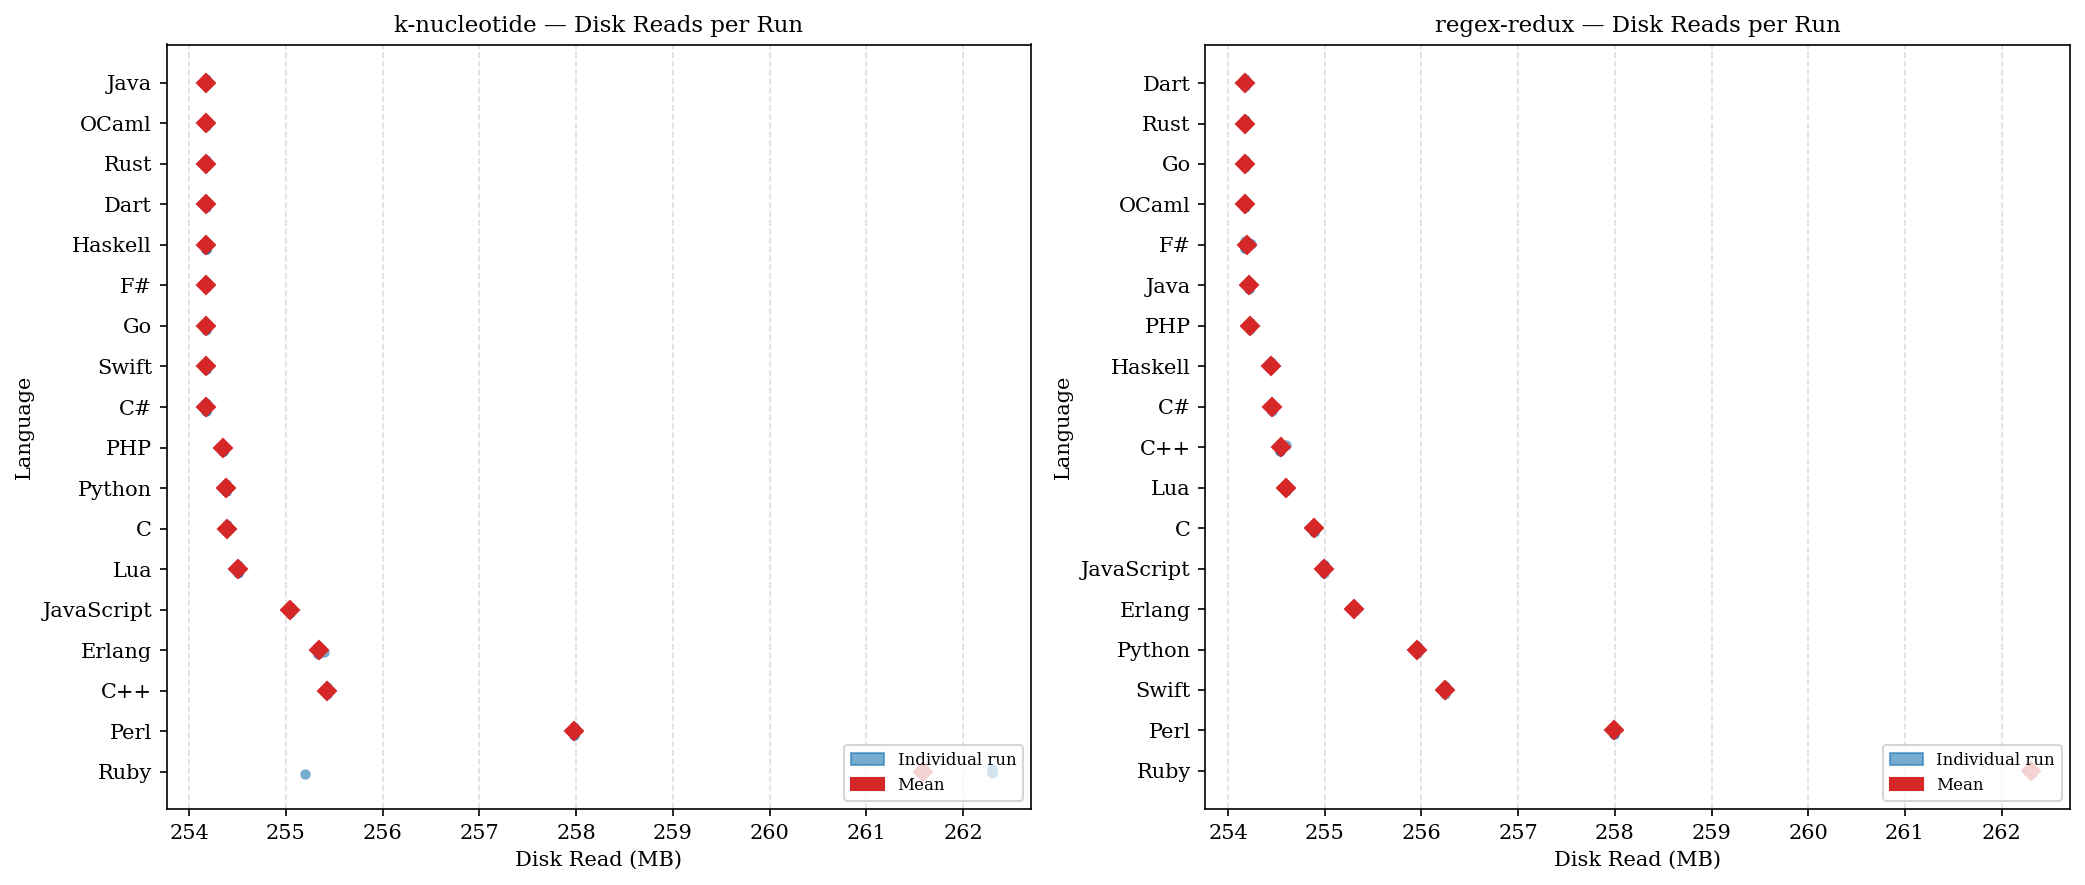

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, bm in zip(axes, IO_BENCHMARKS):
    sub  = io_runs[io_runs['benchmark'] == bm]
    mn   = means[means['benchmark'] == bm].set_index('language')
    order = mn[COL_R].sort_values().index.tolist()

    sns.stripplot(
        data=sub, x=COL_R, y='language', order=order,
        jitter=True, alpha=0.6, size=5, color='#1f77b4', ax=ax,
    )
    for i, lang in enumerate(order):
        ax.plot(mn.loc[lang, COL_R], i, marker='D', color='#d62728', markersize=6, zorder=5)

    ax.legend(
        handles=[
            mpatches.Patch(color='#1f77b4', alpha=0.6, label='Individual run'),
            mpatches.Patch(color='#d62728',             label='Mean'),
        ],
        loc='lower right', fontsize=8,
    )
    ax.set_title(f'{bm} — Disk Reads per Run')
    ax.set_xlabel('Disk Read (MB)')
    ax.set_ylabel('Language')
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
save('stripplot_io_reads')

### 4b. Ranked bars — disk reads for k-nucleotide & regex-redux

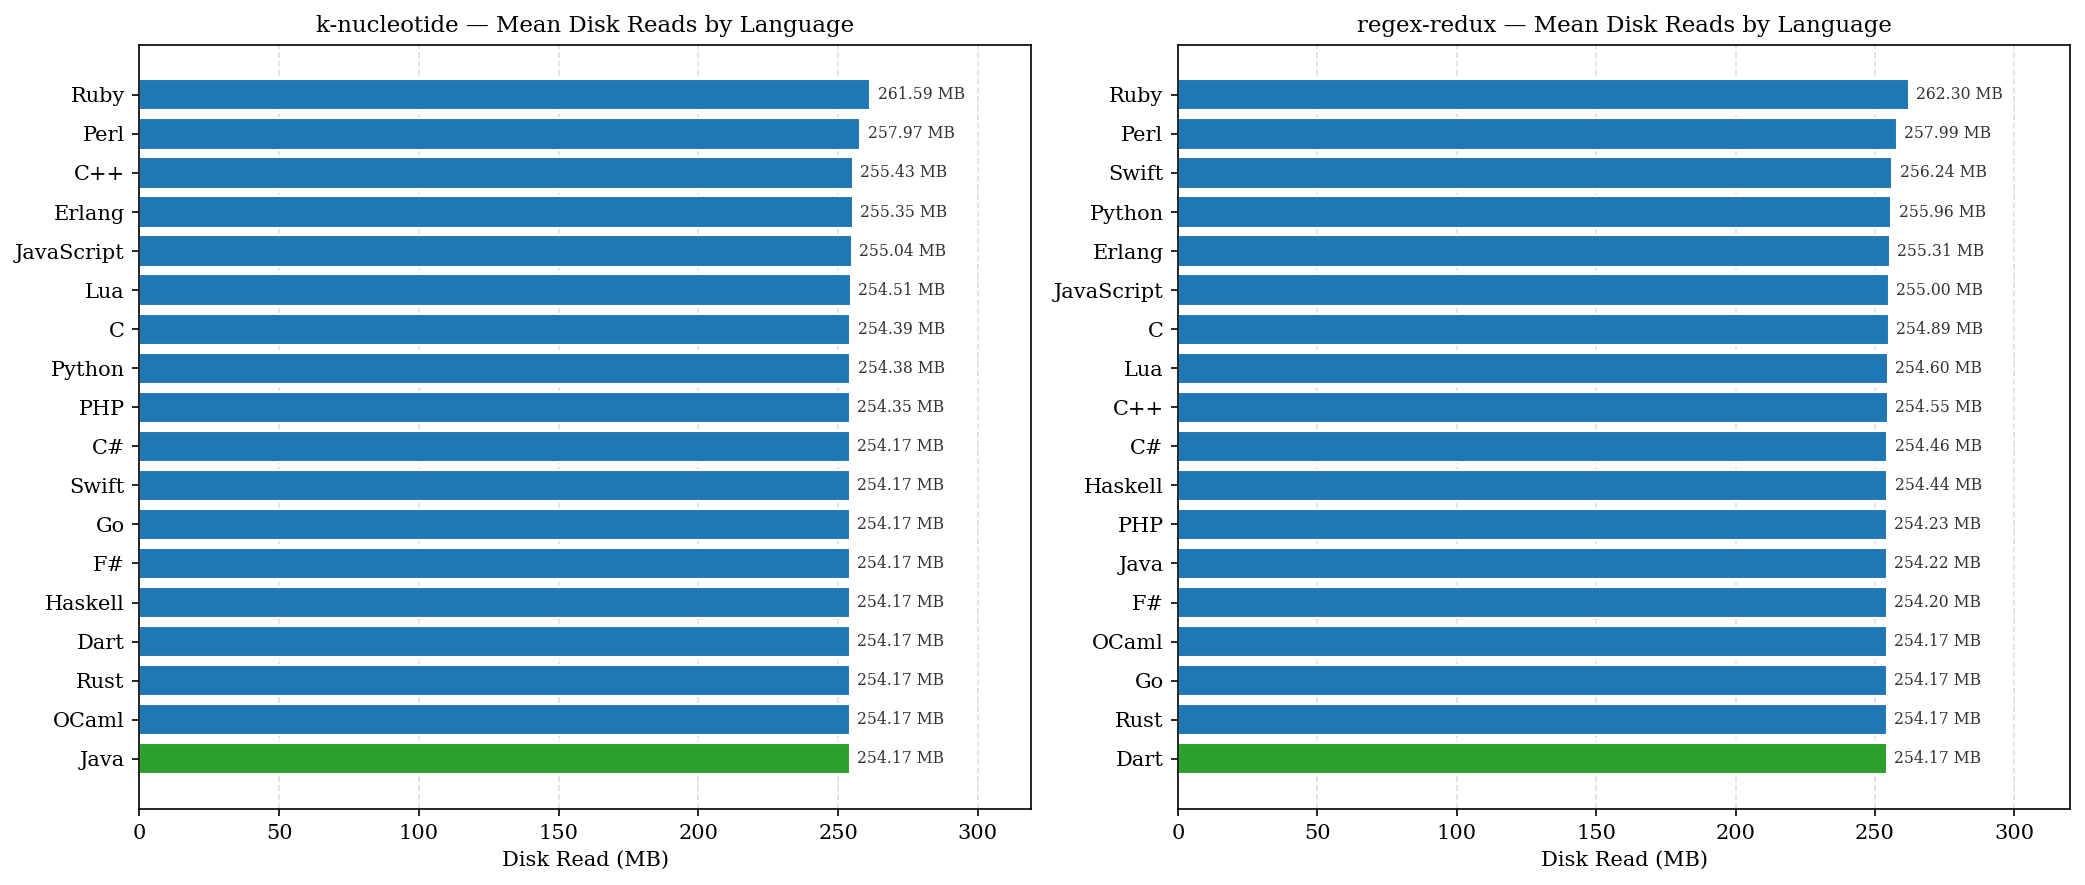

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, bm in zip(axes, IO_BENCHMARKS):
    sub = means[means['benchmark'] == bm].set_index('language')[COL_R].sort_values()
    colors = ['#2ca02c'] + ['#1f77b4'] * (len(sub) - 1)
    bars = ax.barh(sub.index, sub.values, color=colors, edgecolor='white')

    x_max = sub.max()
    for bar, val in zip(bars, sub.values):
        ax.text(
            bar.get_width() + x_max * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f} MB',
            va='center', ha='left', fontsize=7.5, color='#333333',
        )

    ax.set_xlim(0, x_max * 1.22)
    ax.set_title(f'{bm} — Mean Disk Reads by Language')
    ax.set_xlabel('Disk Read (MB)')
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
save('bar_io_reads')

### 4c. Disk reads vs. execution time — do languages that read more also run slower?

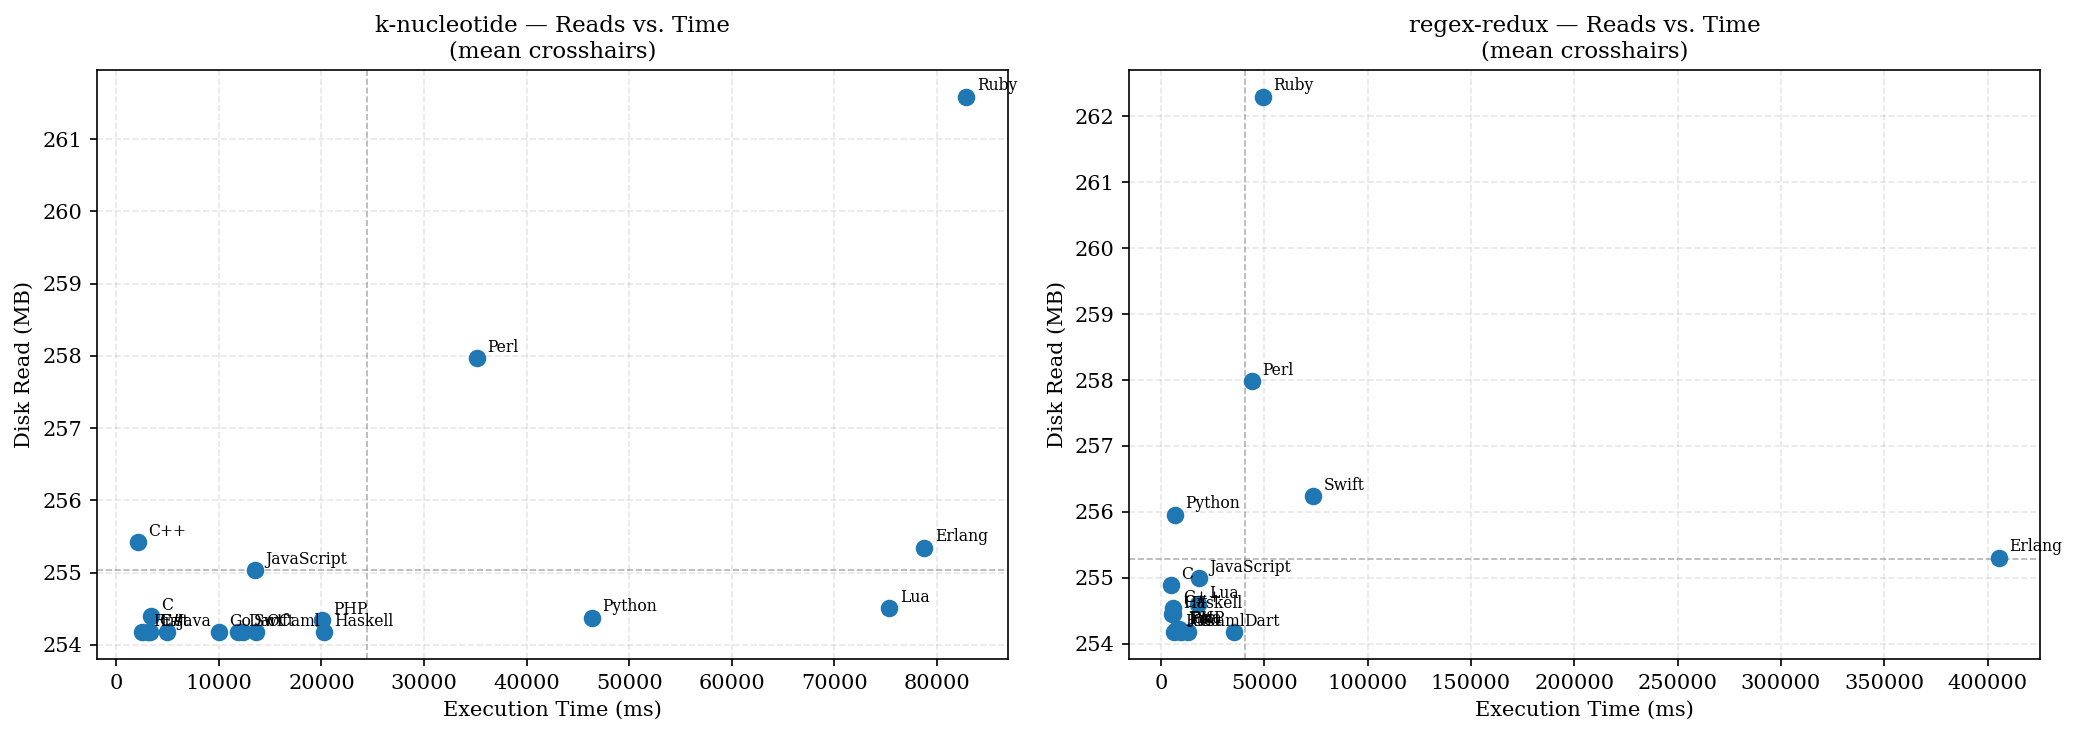

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, bm in zip(axes, IO_BENCHMARKS):
    sub = means[means['benchmark'] == bm].set_index('language')[[COL_R, COL_TIME]]

    ax.scatter(sub[COL_TIME], sub[COL_R], color='#1f77b4', s=55, zorder=3)
    for lang, row in sub.iterrows():
        ax.annotate(
            lang,
            (row[COL_TIME], row[COL_R]),
            textcoords='offset points', xytext=(5, 3), fontsize=7.5,
        )

    ax.axvline(sub[COL_TIME].mean(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(sub[COL_R].mean(),    color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

    ax.set_xlabel('Execution Time (ms)')
    ax.set_ylabel('Disk Read (MB)')
    ax.set_title(f'{bm} — Reads vs. Time\n(mean crosshairs)')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
save('scatter_reads_vs_time')

---
## 5. Disk writes — all benchmarks

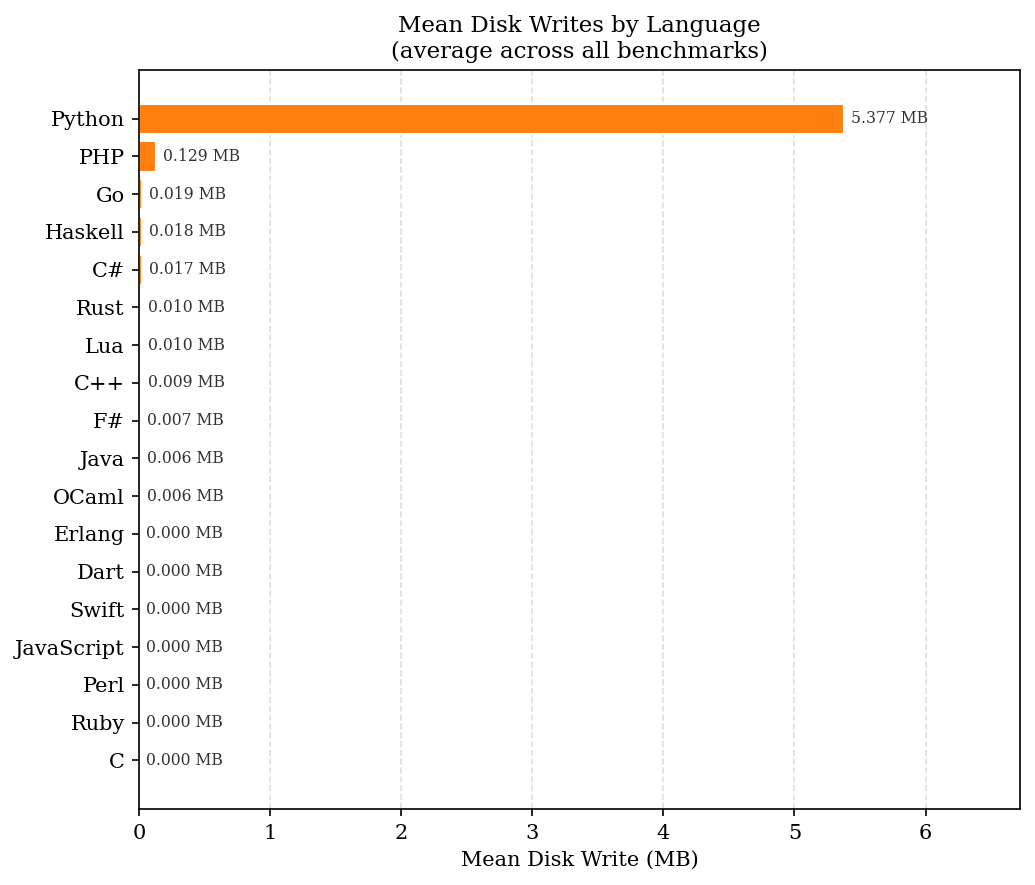

In [21]:
# Ranked bar of mean disk writes per language (averaged across all benchmarks)
write_agg = means.groupby('language')[COL_W].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#2ca02c'] + ['#ff7f0e'] * (len(write_agg) - 1)
bars = ax.barh(write_agg.index, write_agg.values, color=colors, edgecolor='white')

x_max = write_agg.max()
for bar, val in zip(bars, write_agg.values):
    ax.text(
        bar.get_width() + x_max * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f} MB',
        va='center', ha='left', fontsize=7.5, color='#333333',
    )

ax.set_xlim(0, x_max * 1.25)
ax.set_xlabel('Mean Disk Write (MB)')
ax.set_title('Mean Disk Writes by Language\n(average across all benchmarks)')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('bar_disk_writes_all')

---
## 6. Summary table — mean reads & writes per language across all benchmarks

In [22]:
summary = (
    means.groupby('language')[[COL_R, COL_W]]
         .mean()
         .round(3)
         .sort_values(COL_R)
)
summary.columns = ['Mean Read (MB)', 'Mean Write (MB)']

# Also add the I/O-heavy benchmark reads separately for context
for bm in IO_BENCHMARKS:
    col_name = f'Read {bm} (MB)'
    summary[col_name] = (
        means[means['benchmark'] == bm]
        .set_index('language')[COL_R]
        .round(3)
    )

summary

,Mean Read (MB),Mean Write (MB),Read k-nucleotide (MB),Read regex-redux (MB)
language,,,,
Dart,63.543,0.000,254.173,254.173
OCaml,63.543,0.006,254.173,254.173
Go,63.543,0.019,254.173,254.173
Rust,63.543,0.010,254.173,254.173
F#,63.547,0.007,254.173,254.198
Java,63.549,0.006,254.173,254.222
Haskell,63.577,0.018,254.173,254.444
C#,63.579,0.017,254.173,254.456
PHP,63.644,0.129,254.345,254.226


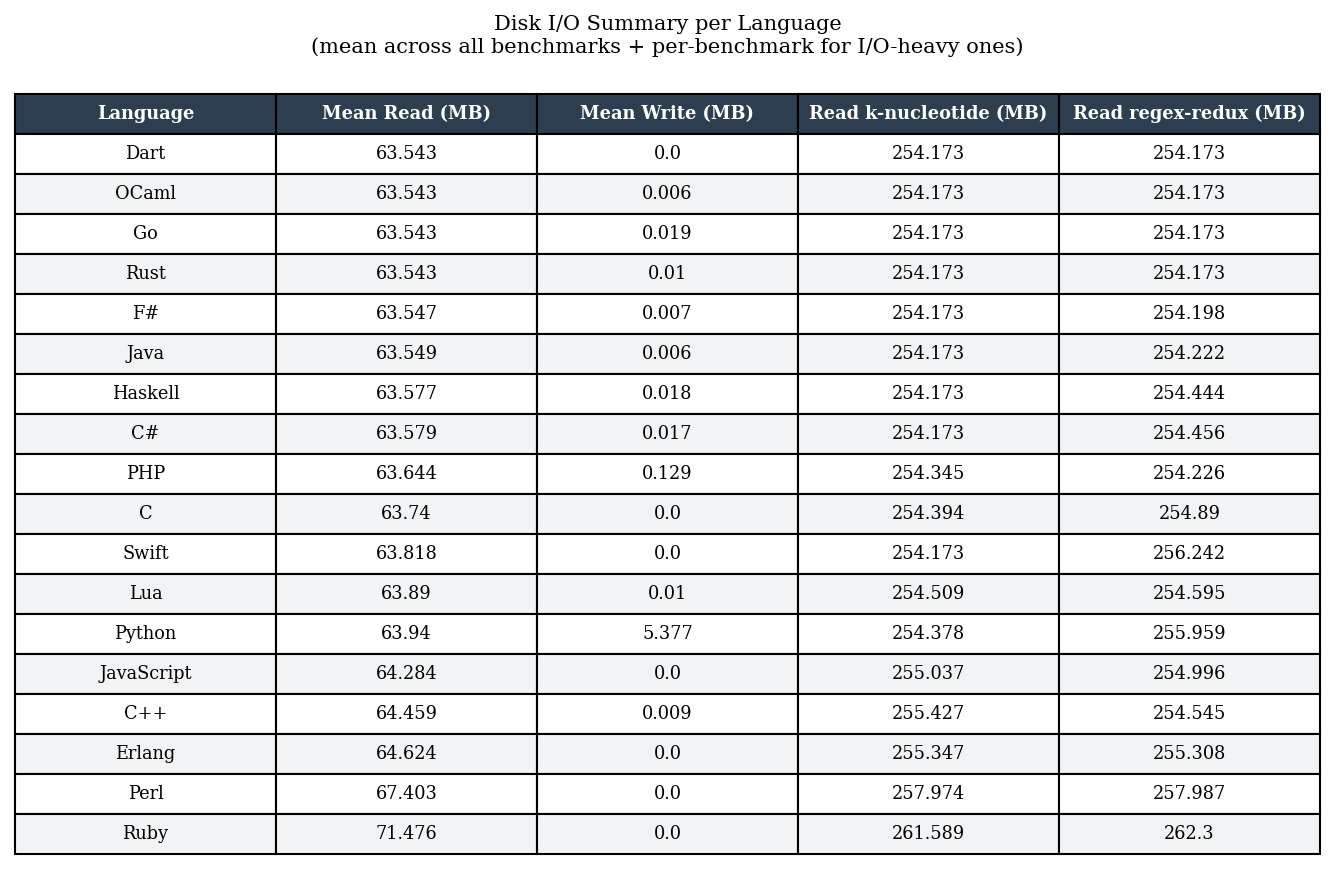

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.axis('off')

summary_reset = summary.reset_index().rename(columns={'language': 'Language'})

table = ax.table(
    cellText=summary_reset.values,
    colLabels=summary_reset.columns,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.4)

# Header styling
for col in range(len(summary_reset.columns)):
    table[(0, col)].set_facecolor('#2c3e50')
    table[(0, col)].set_text_props(color='white', fontweight='bold')

# Alternating rows
for row in range(1, len(summary_reset) + 1):
    for col in range(len(summary_reset.columns)):
        table[(row, col)].set_facecolor('#f2f3f4' if row % 2 == 0 else 'white')

ax.set_title(
    'Disk I/O Summary per Language\n'
    '(mean across all benchmarks + per-benchmark for I/O-heavy ones)',
    fontsize=10, pad=12,
)
plt.tight_layout()
save('summary_table_disk_io')

---
## 7. Runtime startup disk overhead per language

Benchmarks that read **no input file** (binary-trees, fannkuch-redux, fasta, mandelbrot, n-body, spectral-norm) only touch disk to load the language runtime itself. Their mean disk reads therefore isolate the pure **interpreter/runtime startup overhead** — independent of what the benchmark actually does.

This explains why Ruby reads ~8 MB more than the other languages even on k-nucleotide and regex-redux: that overhead is always added on top of the input file size.

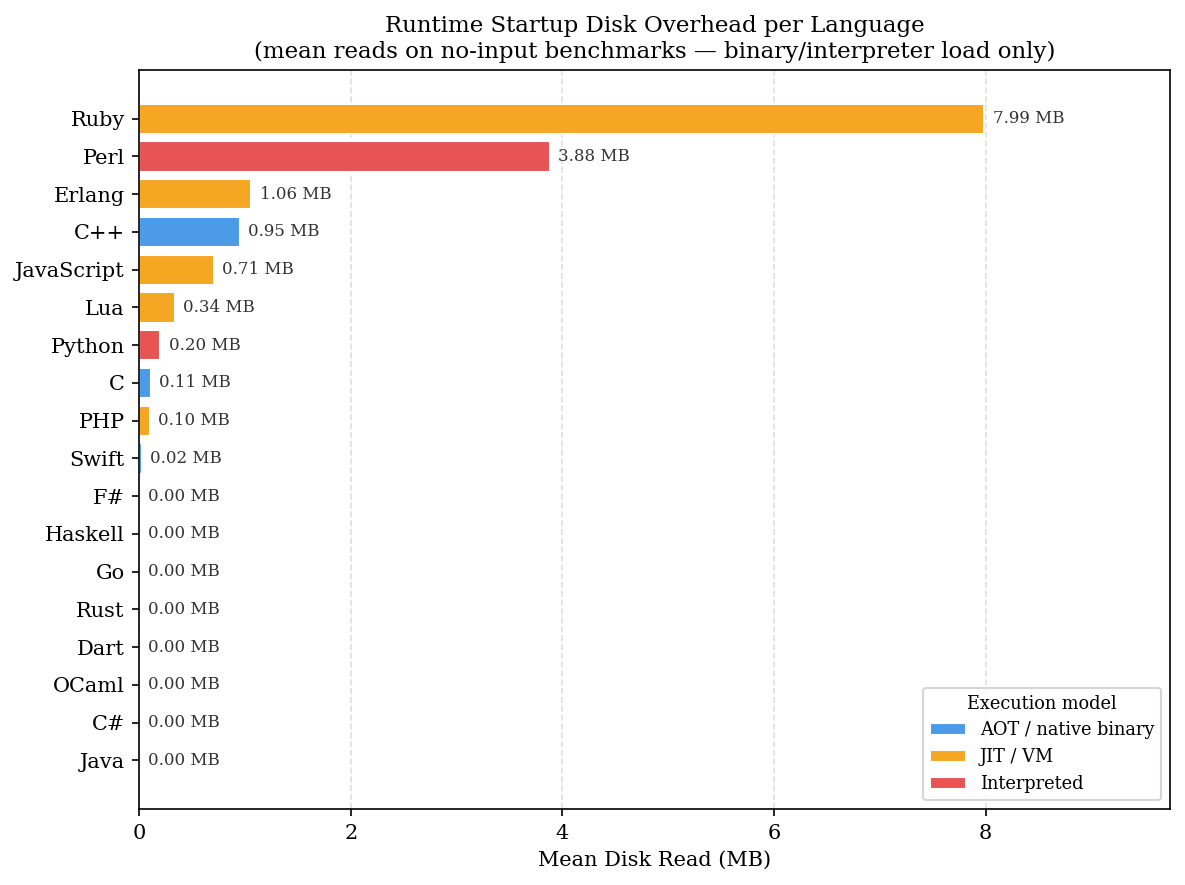

In [24]:
# Execution-model tier colours (consistent with 02_visualization)
AOT         = {'C', 'C++', 'Rust', 'Go', 'Haskell', 'Swift', 'Dart', 'OCaml', 'Java', 'C#', 'F#'}
JIT_VM      = {'Erlang', 'JavaScript', 'Ruby', 'PHP', 'Lua'}
INTERPRETED = {'Python', 'Perl'}

TIER_COLOR = {
    'aot'        : '#4c9be8',   # blue
    'jit'        : '#f5a623',   # orange
    'interpreted': '#e85454',   # red
}
TIER_LABEL = {
    'aot': 'AOT / native binary', 'jit': 'JIT / VM', 'interpreted': 'Interpreted',
}

def bar_color(lang: str) -> str:
    if lang in AOT:         return TIER_COLOR['aot']
    if lang in JIT_VM:      return TIER_COLOR['jit']
    if lang in INTERPRETED: return TIER_COLOR['interpreted']
    return '#aaaaaa'

# Benchmarks with no input file — reads here = pure runtime startup cost
NO_INPUT = ['binary-trees', 'fannkuch-redux', 'fasta', 'mandelbrot', 'n-body', 'spectral-norm']

startup_overhead = (
    means[means['benchmark'].isin(NO_INPUT)]
    .groupby('language')[COL_R]
    .mean()
    .sort_values()
)

colors = [bar_color(l) for l in startup_overhead.index]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(startup_overhead.index, startup_overhead.values, color=colors, edgecolor='white')

x_max = startup_overhead.max()
for bar, val in zip(bars, startup_overhead.values):
    ax.text(
        bar.get_width() + x_max * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f} MB',
        va='center', ha='left', fontsize=8, color='#333333',
    )

ax.set_xlim(0, x_max * 1.22)
ax.set_xlabel('Mean Disk Read (MB)')
ax.set_title(
    'Runtime Startup Disk Overhead per Language\n'
    '(mean reads on no-input benchmarks — binary/interpreter load only)',
)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Legend by tier
legend_handles = [
    mpatches.Patch(facecolor=TIER_COLOR[t], edgecolor='white', label=TIER_LABEL[t])
    for t in ('aot', 'jit', 'interpreted')
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8.5,
          title='Execution model', title_fontsize=8.5)

plt.tight_layout()
save('bar_runtime_startup_overhead')